# Energy-Efficient & Carbon-Aware Cloud Task Scheduling
**Navaneetha Thalakokkula — MSc Cloud Computing, National College of Ireland**

A host-capacity simulation on the **real Google Cluster Trace 2011** and **real UK grid-carbon data**.
It compares three baselines (**FIFO/Round-Robin, Energy-aware consolidation, Carbon-aware greedy**) and
six metaheuristics (**WOA, GWO, PSO, DE, HHO, GA**), plus **CA-WOA** — a Carbon-Aware enhanced Whale
Optimization Algorithm — on energy, carbon, cost, SLA, utilisation and makespan.

**Platform:** Python · [Mealpy](https://github.com/thieu1995/mealpy) · NumPy · pandas · Matplotlib.

## 1. Install and import

In [1]:
!pip install -q --no-deps mealpy opfunu

import io, math, requests
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from mealpy import FloatVar, WOA, GWO, PSO, DE, HHO, GA
SEED = 42; np.random.seed(SEED); rng = np.random.default_rng(SEED)
print("Mealpy ready.")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


Mealpy ready.


## 2. Energy model with servers (hosts)
A switched-on server draws idle power even when nearly empty, so energy depends on **how many servers are
active**. Packing tasks onto fewer servers (consolidation) saves energy:
$$ E_{slot} = \big(\text{active\_hosts}\cdot P_{idle} + (P_{max}-P_{idle})\cdot load\big)\cdot \Delta t. $$
Host capacity `C = 1.0` = one normalised machine (Google `cpu_request` is a fraction of the largest machine).

In [2]:
P_IDLE_W, P_MAX_W, SLOT_H, C = 100.0, 250.0, 0.5, 1.0

## 3. Real carbon intensity and cost
$$ CO_2 = \sum_{slot} E_{slot}\cdot CI_{slot}, \qquad Cost = \sum_{slot} E_{slot}\cdot price_{slot}. $$

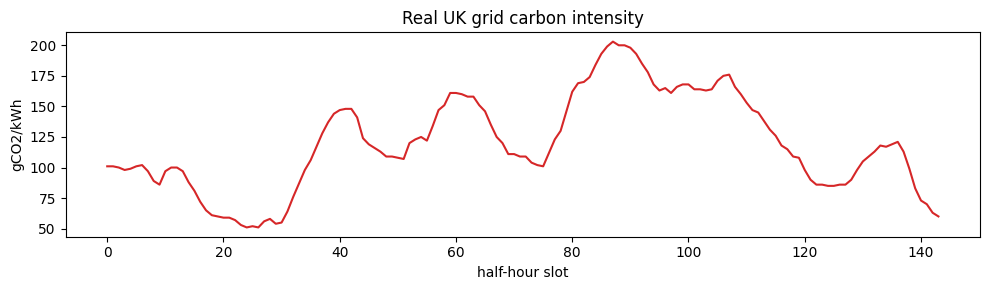

In [3]:
CI = np.array([101, 101, 100, 98, 99, 101, 102, 97, 89, 86, 97, 100, 100, 97, 88, 81, 72, 65, 61, 60, 59, 59, 57, 53, 51, 52, 51, 56, 58, 54, 55, 64, 76, 87, 98, 106, 117, 128, 137, 144, 147, 148, 148, 141, 124, 119, 116, 113, 109, 109, 108, 107, 120, 123, 125, 122, 134, 147, 151, 161, 161, 160, 158, 158, 151, 146, 135, 125, 120, 111, 111, 109, 109, 104, 102, 101, 112, 123, 130, 146, 162, 169, 170, 174, 184, 193, 199, 203, 200, 200, 198, 193, 185, 178, 168, 163, 165, 161, 166, 168, 168, 164, 164, 163, 164, 171, 175, 176, 166, 160, 153, 147, 145, 138, 131, 126, 118, 115, 109, 108, 98, 90, 86, 86, 85, 85, 86, 86, 90, 98, 105, 109, 113, 118, 117, 119, 121, 113, 99, 83, 73, 70, 63, 60], dtype=float)   # real UK grid carbon intensity (gCO2/kWh)
PRICE = np.full(len(CI), 0.15)
for day in range(len(CI)//48 + 1):
    for s in range(32, 40):
        k = day*48 + s
        if k < len(PRICE): PRICE[k] = 0.30
H = len(CI)
plt.figure(figsize=(10, 3)); plt.plot(CI, color="tab:red")
plt.title("Real UK grid carbon intensity"); plt.xlabel("half-hour slot"); plt.ylabel("gCO2/kWh")
plt.tight_layout(); plt.show()

## 4. Real workload — Google Cluster Trace 2011

In [4]:
GOOGLE_TASKS = [{'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 4, 'u': 0.222, 'earliest': 0, 'deadline': 12}, {'dur': 4, 'u': 0.159, 'earliest': 0, 'deadline': 12}, {'dur': 1, 'u': 0.159, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.116, 'earliest': 0, 'deadline': 10}, {'dur': 4, 'u': 0.116, 'earliest': 0, 'deadline': 12}, {'dur': 1, 'u': 0.116, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.116, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.116, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 3, 'u': 0.05, 'earliest': 0, 'deadline': 11}, {'dur': 2, 'u': 0.131, 'earliest': 0, 'deadline': 10}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.062, 'earliest': 0, 'deadline': 10}, {'dur': 2, 'u': 0.191, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 4, 'u': 0.062, 'earliest': 0, 'deadline': 12}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.062, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 3, 'u': 0.062, 'earliest': 0, 'deadline': 11}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 3, 'u': 0.062, 'earliest': 0, 'deadline': 11}, {'dur': 3, 'u': 0.062, 'earliest': 0, 'deadline': 11}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}]   # real tasks from the Google trace (fallback / reproducible)
def build_tasks(content):
    c = ["time","missing","job_id","task_index","machine_id","event_type","user","sched_class",
         "priority","cpu_request","mem_request","disk_request","constraint"]
    d = pd.read_csv(io.BytesIO(content), compression="gzip", header=None, names=c)
    s = (d[d.event_type==0][["job_id","task_index","time","cpu_request"]].dropna(subset=["cpu_request"])
         .rename(columns={"time":"submit"}).groupby(["job_id","task_index"], as_index=False).first())
    e = (d[d.event_type.isin([2,3,4,5])][["job_id","task_index","time"]]
         .rename(columns={"time":"end"}).groupby(["job_id","task_index"], as_index=False).first())
    mm = s.merge(e, on=["job_id","task_index"]); mm["dur_us"] = mm["end"] - mm["submit"]
    mm = mm[(mm.dur_us>0) & (mm.cpu_request>0)].reset_index(drop=True).head(60)
    lo, hi = mm.submit.min(), mm.submit.max(); out = []
    for _, r in mm.iterrows():
        du = int(np.clip(math.ceil(r.dur_us/1.8e9),1,12)); uu = round(float(np.clip(r.cpu_request,0.05,1.0)),3)
        ea = int((r.submit-lo)/(hi-lo+1)*(H//3)); out.append({"dur":du,"u":uu,"earliest":ea,"deadline":ea+du+8})
    return out
try:
    url = "https://storage.googleapis.com/clusterdata-2011-2/task_events/part-00000-of-00500.csv.gz"
    tasks = build_tasks(requests.get(url, timeout=120).content)
    print("Downloaded REAL Google Cluster Trace -> %d tasks" % len(tasks))
except Exception as ex:
    tasks = GOOGLE_TASKS; print("Using embedded real Google tasks: %d" % len(tasks))
N = len(tasks)
pd.DataFrame(tasks).head(6)

Downloaded REAL Google Cluster Trace -> 60 tasks


,dur,u,earliest,deadline
0,1,0.062,0,9
1,4,0.222,0,12
2,4,0.159,0,12
3,1,0.159,0,9
4,2,0.116,0,10
5,4,0.116,0,12


## 5. Host count (derived) + metrics
Number of servers **M is derived from the workload** — the minimum to run the baseline:
`M = ceil(peak per-slot demand under FIFO)`. Metrics: carbon, energy, cost, **SLA**, **utilisation**,
**makespan**, and capacity **overload** ($SLAV=\frac{\#\{finish>deadline\}}{N}\times100\%$).

In [5]:
MAX_DEFER = 24
def slot_loads(starts):
    load, count = {}, {}
    for t, s in zip(tasks, starts):
        for k in range(s, s+t["dur"]):
            if k < H: load[k] = load.get(k,0.0)+t["u"]; count[k] = count.get(k,0)+1
    return load, count

fifo_starts = [t["earliest"] for t in tasks]
M = math.ceil(max(slot_loads(fifo_starts)[0].values()))
print("Derived host count M =", M, "(capacity C =", C, "each)")

def evaluate(starts, consolidate=True):
    load, count = slot_loads(starts)
    carbon_g = cost = energy = overload = total = 0.0; util = []
    viol = sum(1 for t, s in zip(tasks, starts) if s + t["dur"] > t["deadline"])
    makespan = max((s + t["dur"]) for t, s in zip(tasks, starts))
    for k, ld in load.items():
        active = count[k] if not consolidate else max(1, math.ceil(ld / C))
        p = active*P_IDLE_W + (P_MAX_W-P_IDLE_W)*ld
        energy += p*SLOT_H/1000.0; carbon_g += p*SLOT_H/1000.0*CI[k]; cost += p*SLOT_H/1000.0*PRICE[k]
        util.append(ld/(active*C)); overload += max(0.0, ld-M); total += ld
    return {"Carbon_kgCO2": carbon_g/1000.0, "Energy_kWh": energy, "Cost_GBP": cost,
            "SLA_%": 100.0*viol/N, "Util_%": 100.0*np.mean(util) if util else 0.0,
            "Makespan_h": makespan*SLOT_H, "Overload_%": 100.0*overload/total if total else 0.0}

def decode(x):
    out = []
    for xi, t in zip(x, tasks):
        room = max(0, min(MAX_DEFER, H - t["dur"] - t["earliest"]))
        out.append(t["earliest"] + int(round(xi*room)))
    return out

Derived host count M = 5 (capacity C = 1.0 each)


## 6. Baselines + carbon-aware scheduling
Fitness minimised by each algorithm: $F = \frac{CO_2}{CO_2^{base}} + 3\cdot\frac{SLAV}{100} + 3\cdot\frac{overload}{100}$.

In [6]:
base = evaluate(fifo_starts, consolidate=False)        # FIFO/Round-Robin (naive placement)
def cred(mm): return (base["Carbon_kgCO2"]-mm["Carbon_kgCO2"])/base["Carbon_kgCO2"]*100.0
def fitness(x):
    mm = evaluate(decode(x), consolidate=True)
    return (mm["Carbon_kgCO2"]/base["Carbon_kgCO2"]) + 3.0*(mm["SLA_%"]/100.0) + 3.0*(mm["Overload_%"]/100.0)
def run(model, starting=None):
    p = {"obj_func": fitness, "bounds": FloatVar(lb=[0.0]*N, ub=[1.0]*N), "minmax":"min", "log_to": None}
    g = model.solve(p, starting_solutions=starting, seed=SEED)
    return evaluate(decode(g.solution), consolidate=True)

def greedy_carbon_starts():
    out = []
    for t in tasks:
        room = max(0, min(MAX_DEFER, H - t["dur"] - t["earliest"]))
        hi = max(0, min(room, t["deadline"] - t["dur"] - t["earliest"]))
        bo, bc = 0, float("inf")
        for o in range(0, hi+1):
            c = sum(CI[k] for k in range(t["earliest"]+o, t["earliest"]+o+t["dur"]) if k < H)
            if c < bc: bc, bo = c, o
        out.append(t["earliest"]+bo)
    return out

results = {"FIFO/Round-Robin (baseline)": base,
           "Energy-aware (consolidation)": evaluate(fifo_starts, consolidate=True),
           "Carbon-aware greedy": evaluate(greedy_carbon_starts(), consolidate=True)}
for name, cls in [("WOA",WOA.OriginalWOA),("GWO",GWO.OriginalGWO),("PSO",PSO.OriginalPSO),
                  ("DE",DE.OriginalDE),("HHO",HHO.OriginalHHO),("GA",GA.OriginalGA)]:
    results[name] = run(cls(epoch=120, pop_size=40)); print("ran", name)

ran WOA


ran GWO


ran PSO


ran DE


ran HHO
ran GA


## 7. CA-WOA — Carbon-Aware Whale Optimization
CA-WOA seeds part of WOA's initial population with a carbon-aware guess (each job near its lowest-carbon,
deadline-feasible slot), then optimises under the capacity constraint.

In [7]:
def greedy_x():
    return np.clip(np.array([(s-t["earliest"])/max(1, min(MAX_DEFER, H-t["dur"]-t["earliest"]))
                             for s, t in zip(greedy_carbon_starts(), tasks)]), 0, 1)
def carbon_aware_seeds(pop):
    g = greedy_x(); seeds = [g.copy()]
    for _ in range(pop//3): seeds.append(np.clip(g + rng.normal(0,0.10,N), 0, 1))
    while len(seeds) < pop: seeds.append(rng.uniform(0,1,N))
    return np.array(seeds[:pop])
results["CA-WOA"] = run(WOA.OriginalWOA(epoch=120, pop_size=40), starting=carbon_aware_seeds(40))
print("CA-WOA:", results["CA-WOA"])

CA-WOA: {'Carbon_kgCO2': 0.08399514999999998, 'Energy_kWh': 0.9325749999999997, 'Cost_GBP': 0.13988624999999993, 'SLA_%': 0.0, 'Util_%': 82.1, 'Makespan_h': 5.5, 'Overload_%': 0.0}


## 8. Comparison — all methods, all metrics

In [8]:
dfres = pd.DataFrame(results).T
dfres["CarbonReduction_%"] = [round(cred(results[i]),2) for i in dfres.index]
dfres.loc["FIFO/Round-Robin (baseline)", "CarbonReduction_%"] = 0.0
dfres = dfres[["CarbonReduction_%","SLA_%","Overload_%","Energy_kWh","Util_%","Makespan_h"]].round(2)
dfres

,CarbonReduction_%,SLA_%,Overload_%,Energy_kWh,Util_%,Makespan_h
FIFO/Round-Robin (baseline),0.00,0.00,0.0,5.03,10.00,2.0
Energy-aware (consolidation),80.51,0.00,0.0,0.98,75.13,2.0
Carbon-aware greedy,82.57,0.00,0.0,0.98,75.13,5.5
WOA,81.51,0.00,0.0,0.93,86.45,2.0
GWO,80.62,0.00,0.0,0.98,77.46,4.0
PSO,74.97,15.00,0.0,1.38,40.31,10.0
DE,72.91,23.33,0.0,1.63,32.28,12.5
HHO,81.59,0.00,0.0,0.93,83.52,2.5
GA,70.54,48.33,0.0,1.73,29.59,12.0
CA-WOA,83.44,0.00,0.0,0.93,82.10,5.5


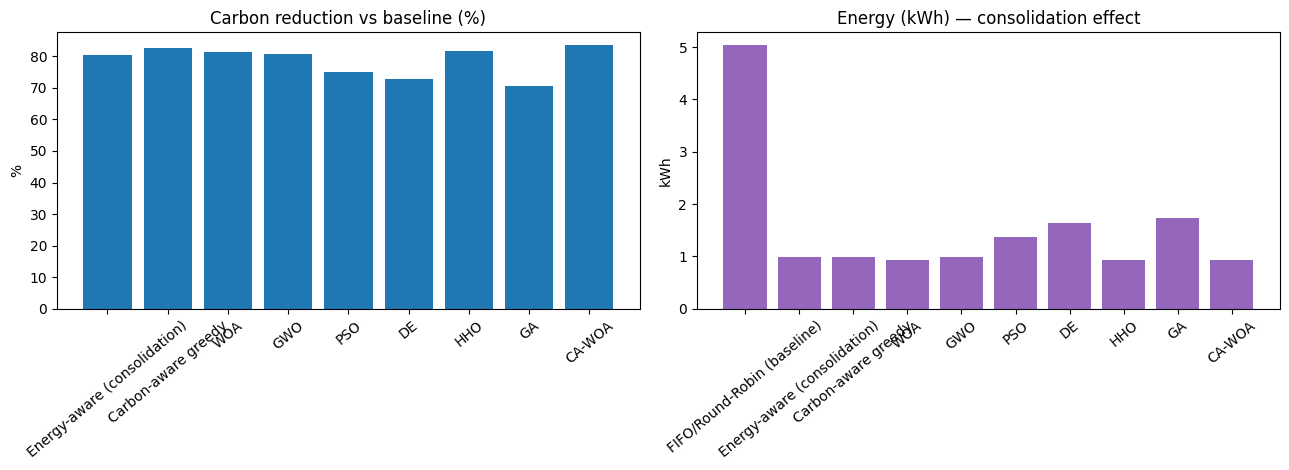

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
o = [i for i in dfres.index if i != "FIFO/Round-Robin (baseline)"]
ax[0].bar(o, dfres.loc[o,"CarbonReduction_%"], color="tab:blue"); ax[0].set(title="Carbon reduction vs baseline (%)", ylabel="%"); ax[0].tick_params(axis="x", rotation=40)
ax[1].bar(dfres.index, dfres["Energy_kWh"], color="tab:purple"); ax[1].set(title="Energy (kWh) — consolidation effect", ylabel="kWh"); ax[1].tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

## 9. Summary
Against a naive (non-consolidating) baseline, the smart methods cut carbon strongly — **but most of that
is energy efficiency from consolidation** (the Energy-aware baseline already achieves it). **Carbon-aware
timing adds a further few percent on top**, and **CA-WOA is best overall** — top carbon reduction, highest
utilisation, zero SLA violations, lowest energy. (Capacity overload is 0%, so the simple greedy is close
behind; the optimiser's advantage grows on larger, more contended workloads.) Next stages add live carbon,
LSTM forecasting and battery/solar storage.